In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers import DualityGapStopping
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.linear.proximal_gradient import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
from comparison_plot import comparison_plot
import logging

# Generate a test image as exact solution

In [2]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.925)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 50*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


# Generate synthetic data with impulsive noise

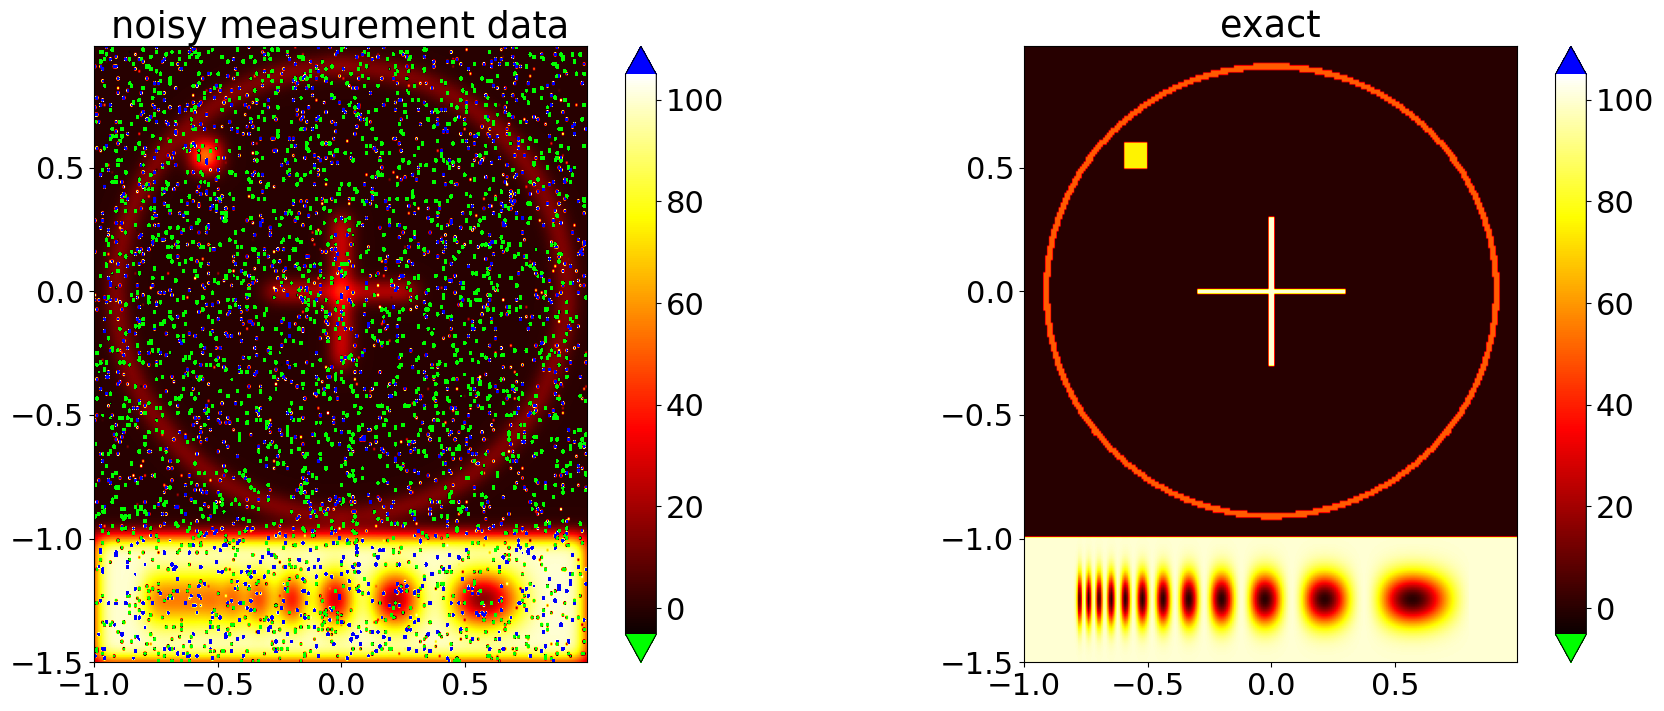

In [3]:
a=0.05
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
data = blur.copy()
n,m=grid.shape
for j in range(64**2):
    nn = np.random.randint(n)
    mm = np.random.randint(m)
    data[nn,mm] =  np.random.randint(2000)-1000

comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

# Reconstruction with a quadratic data fidelity term
... fails completely for this data!

2024-07-07 17:09:07,930 INFO TikhonovCG           :: it.745 kappa=23.05489948057671 err/Tol rel X:9.9e-07/1.0e-06 
2024-07-07 17:09:07,932 INFO TikhonovCG           :: Solver converged after 745 iteration.


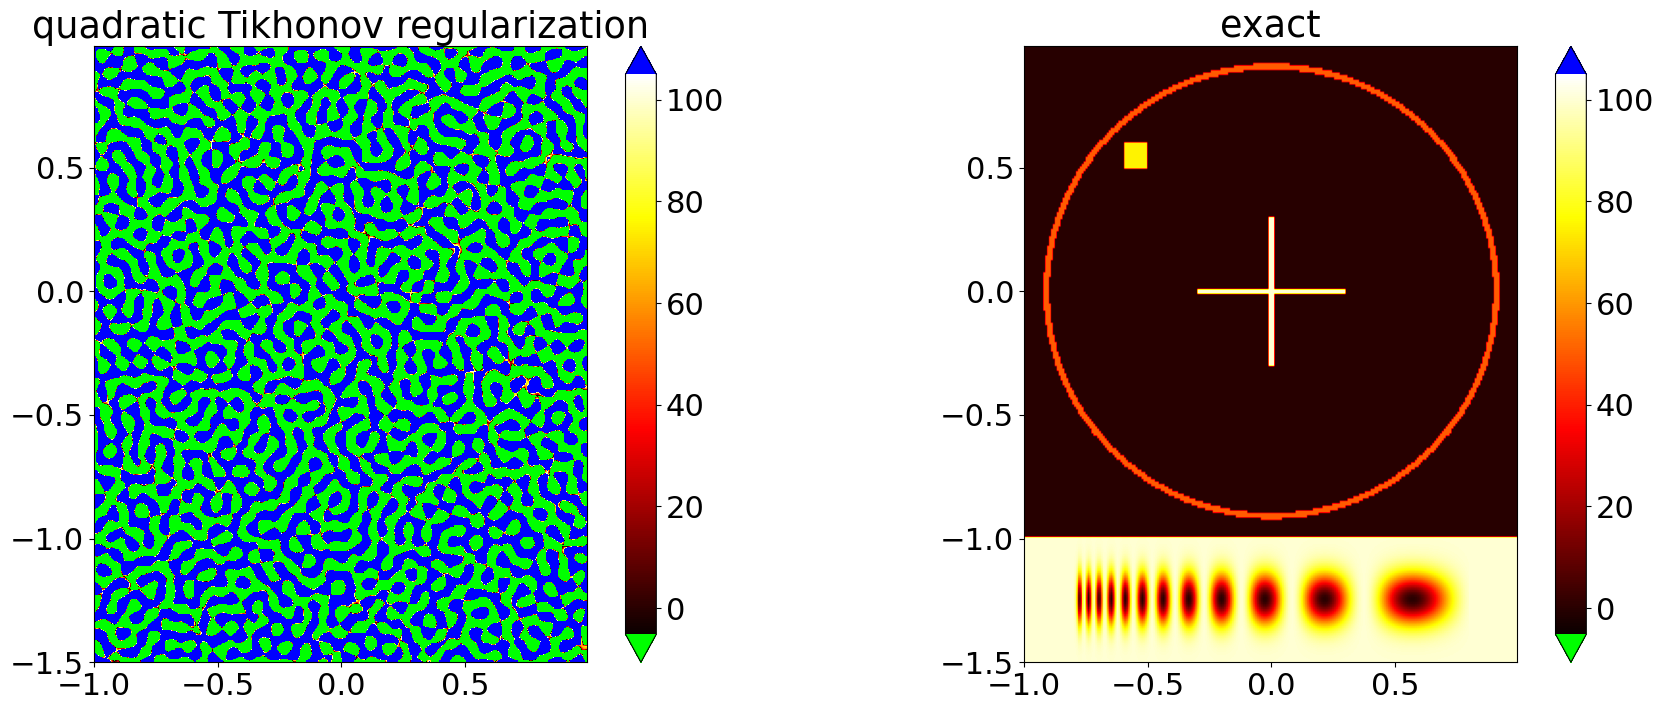

In [4]:
alpha = 1e-4
setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = data, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

comparison_plot(grid,exact_sol,fal,title_left='quadratic Tikhonov regularization')

# setting with Huber data fidelity and quadratic penalty term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [5]:
sigma = 0.1
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma,eps =1e-10)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()

### FISTA applied to primal problem

2024-07-07 17:09:09,349 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=1.011e-01.
 Expected linear convergence rate: 9.968e-01
2024-07-07 17:09:09,416 INFO DualityGapStopping   :: it. 0/400: duality gap=1.107e+08
2024-07-07 17:09:09,417 INFO DualityGapStopping   :: it. 0/400: duality gap=1.107e+08 (1.000e-03)
2024-07-07 17:09:09,500 INFO DualityGapStopping   :: it. 1/400: duality gap=1.025e+08 (1.000e-03)
2024-07-07 17:09:09,616 INFO DualityGapStopping   :: it. 2/400: duality gap=9.826e+07 (1.000e-03)
2024-07-07 17:09:09,709 INFO DualityGapStopping   :: it. 3/400: duality gap=9.454e+07 (1.000e-03)
2024-07-07 17:09:09,768 INFO DualityGapStopping   :: it. 4/400: duality gap=9.146e+07 (1.000e-03)
2024-07-07 17:09:09,827 INFO DualityGapStopping   :: it. 5/400: duality gap=8.888e+07 (1.000e-03)
2024-07-07 17:09:09,874 INFO DualityGapStopping   :: it. 6/400: duality gap=8.654e+07 (1.000e-03)
2024-07-07 17:09:09,922 I

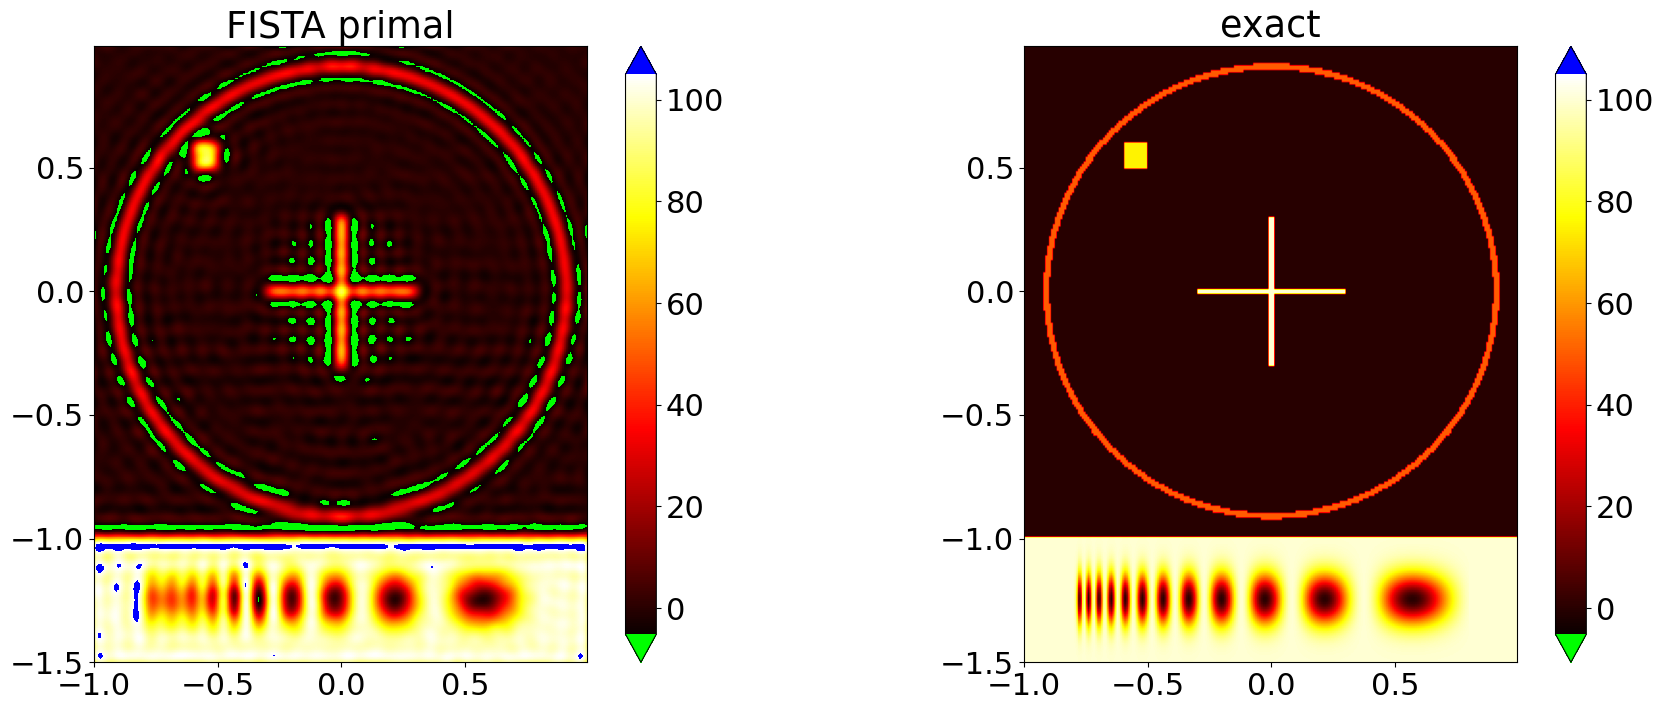

In [6]:
solverFISTA_primal = FISTA(huber_setting,logging_level=logging.DEBUG)
stop_FISTA_primal=DualityGapStopping(solverFISTA_primal,threshold = 1e-3, max_iter=400,logging_level=logging.INFO)
f_FISTA_primal, _= solverFISTA_primal.run(stoprule=stop_FISTA_primal)

comparison_plot(grid,exact_sol,f_FISTA_primal,title_left='FISTA primal')

### FISTA applied to the dual problem

2024-07-07 17:10:22,612 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-05, mu_S=0.000e+00 and step length tau=1.009e+00.
 Expected linear convergence rate: 9.968e-01
2024-07-07 17:10:22,651 INFO DualityGapStopping   :: it. 0/400: duality gap=2.370e+06
2024-07-07 17:10:22,652 INFO DualityGapStopping   :: it. 0/400: duality gap=2.370e+06 (1.000e+00)
2024-07-07 17:10:22,699 INFO DualityGapStopping   :: it. 1/400: duality gap=3.065e+11 (1.000e+00)
2024-07-07 17:10:22,741 INFO DualityGapStopping   :: it. 2/400: duality gap=3.798e+11 (1.000e+00)
2024-07-07 17:10:22,781 INFO DualityGapStopping   :: it. 3/400: duality gap=4.553e+11 (1.000e+00)
2024-07-07 17:10:22,828 INFO DualityGapStopping   :: it. 4/400: duality gap=5.266e+11 (1.000e+00)
2024-07-07 17:10:22,871 INFO DualityGapStopping   :: it. 5/400: duality gap=5.979e+11 (1.000e+00)
2024-07-07 17:10:22,926 INFO DualityGapStopping   :: it. 6/400: duality gap=6.771e+11 (1.000e+00)
2024-07-07 17:10:22,974 I

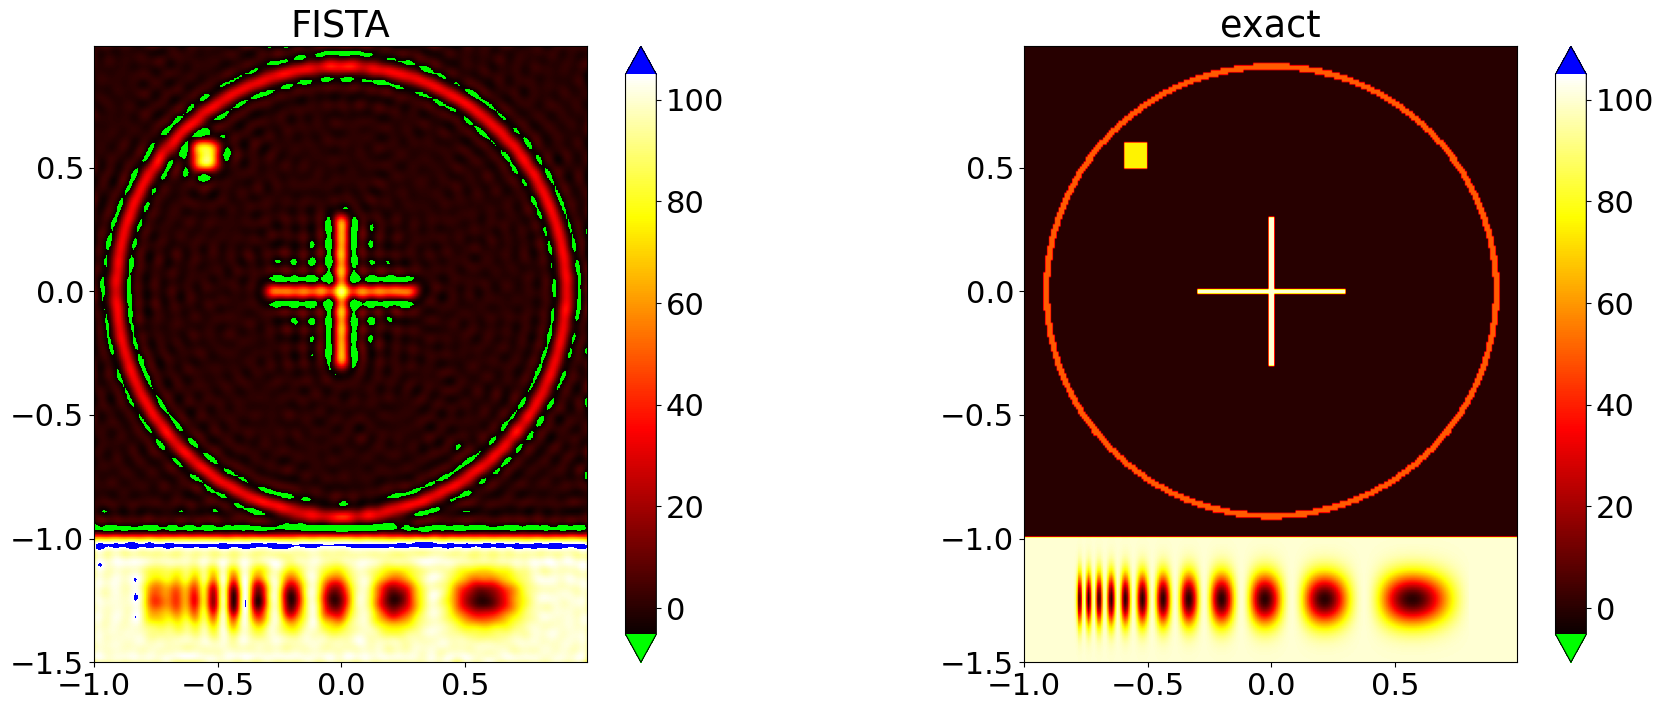

In [9]:
solverFISTA_dual = FISTA(dual_setting,logging_level=logging.DEBUG)
stop_FISTA_dual=DualityGapStopping(solverFISTA_dual,threshold = 1, max_iter=400,logging_level=logging.INFO)
pFISTA_dual, Tstar_pFISTA_dual= solverFISTA_dual.run(stoprule=stop_FISTA_dual)

f_FISTA_dual = huber_setting.dualToPrimal(Tstar_pFISTA_dual,argumentIsOperatorImage=True)
comparison_plot(grid,exact_sol,f_FISTA_dual,title_left='FISTA')

### PDHG


2024-07-07 17:11:25,770 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-05 and ||T||=9.949e-01.
 Expected linear convergence rate: 9.937e-01
2024-07-07 17:11:25,805 INFO DualityGapStopping   :: it. 0/400: duality gap=1.107e+08
2024-07-07 17:11:25,805 INFO DualityGapStopping   :: it. 0/400: duality gap=1.107e+08 (1.000e-03)
2024-07-07 17:11:25,859 INFO DualityGapStopping   :: it. 1/400: duality gap=4.750e+07 (1.000e-03)
2024-07-07 17:11:25,903 INFO DualityGapStopping   :: it. 2/400: duality gap=3.906e+07 (1.000e-03)
2024-07-07 17:11:25,953 INFO DualityGapStopping   :: it. 3/400: duality gap=2.773e+07 (1.000e-03)
2024-07-07 17:11:25,999 INFO DualityGapStopping   :: it. 4/400: duality gap=1.002e+07 (1.000e-03)
2024-07-07 17:11:26,047 INFO DualityGapStopping   :: it. 5/400: duality gap=2.584e+06 (1.000e-03)
2024-07-07 17:11:26,097 INFO DualityGapStopping   :: it. 6/400: duality gap=1.392e+06 (1.000e-03)
2024-07-07 17:11:26,148

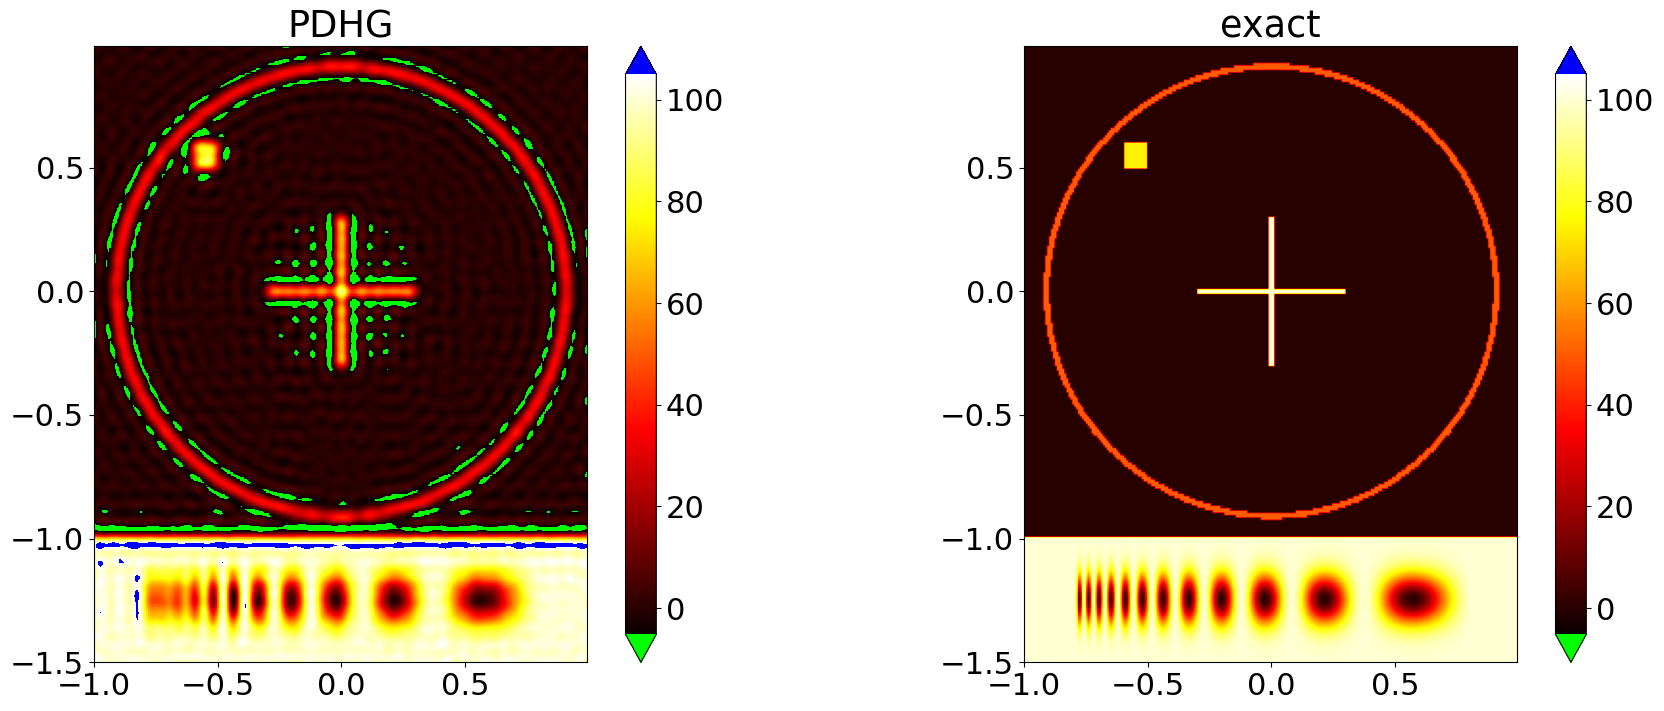

In [10]:
solverPDHG = PDHG(huber_setting,logging_level=logging.INFO)
stop_PDHG=DualityGapStopping(solverPDHG,threshold = 1., max_iter=400,logging_level=logging.INFO)
f_PDHG, _= solverPDHG.run(stoprule=stop_PDHG)

comparison_plot(grid,exact_sol,f_PDHG,title_left='PDHG')

### comparison of convergence rates of minimization methods

Text(0.5, 1.0, 'Huber data fid., quadratic penalty')

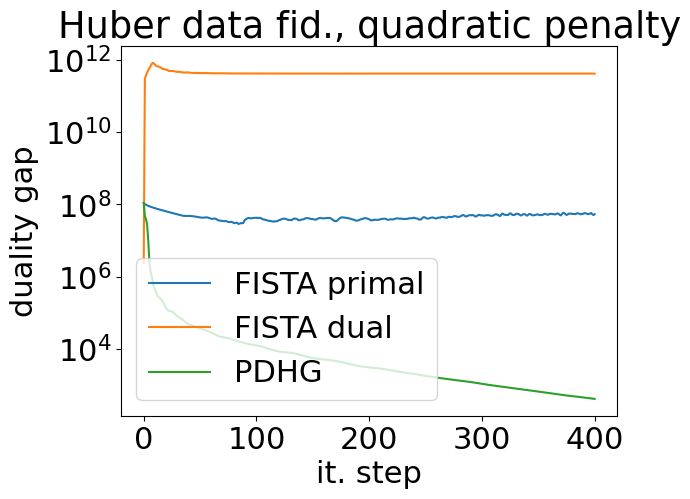

In [11]:
plt.semilogy(stop_FISTA_primal.gap_stat,label='FISTA primal')
plt.semilogy(stop_FISTA_dual.gap_stat,label='FISTA dual')
plt.semilogy(stop_PDHG.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('Huber data fid., quadratic penalty')

# setting with Huber data fidelity and quadratic penalty term with bilateral constraints
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_{0\leq f\leq ub}\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|_{L^2}^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [12]:
sigma = 0.1
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma,eps=1e-10)
Rfun = fct.QuadraticBilateralConstraints(grid,lb=0,ub=100,eps=1e-10)
huber_constr_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data,logging_level=logging.DEBUG)
dual_constr_setting = huber_constr_setting.dualSetting()

### FISTA applied to primal setting 

2024-07-07 17:12:24,107 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=1.005e-01.
 Expected linear convergence rate: 9.968e-01
2024-07-07 17:12:24,147 INFO DualityGapStopping   :: it. 0/400: duality gap=2.637e+06
2024-07-07 17:12:24,148 INFO DualityGapStopping   :: it. 0/400: duality gap=2.637e+06 (1.000e-03)
2024-07-07 17:12:24,199 INFO DualityGapStopping   :: it. 1/400: duality gap=2.405e+06 (1.000e-03)
2024-07-07 17:12:24,245 INFO DualityGapStopping   :: it. 2/400: duality gap=2.293e+06 (1.000e-03)
2024-07-07 17:12:24,292 INFO DualityGapStopping   :: it. 3/400: duality gap=2.188e+06 (1.000e-03)
2024-07-07 17:12:24,339 INFO DualityGapStopping   :: it. 4/400: duality gap=2.100e+06 (1.000e-03)
2024-07-07 17:12:24,394 INFO DualityGapStopping   :: it. 5/400: duality gap=2.035e+06 (1.000e-03)
2024-07-07 17:12:24,441 INFO DualityGapStopping   :: it. 6/400: duality gap=1.981e+06 (1.000e-03)
2024-07-07 17:12:24,490 I

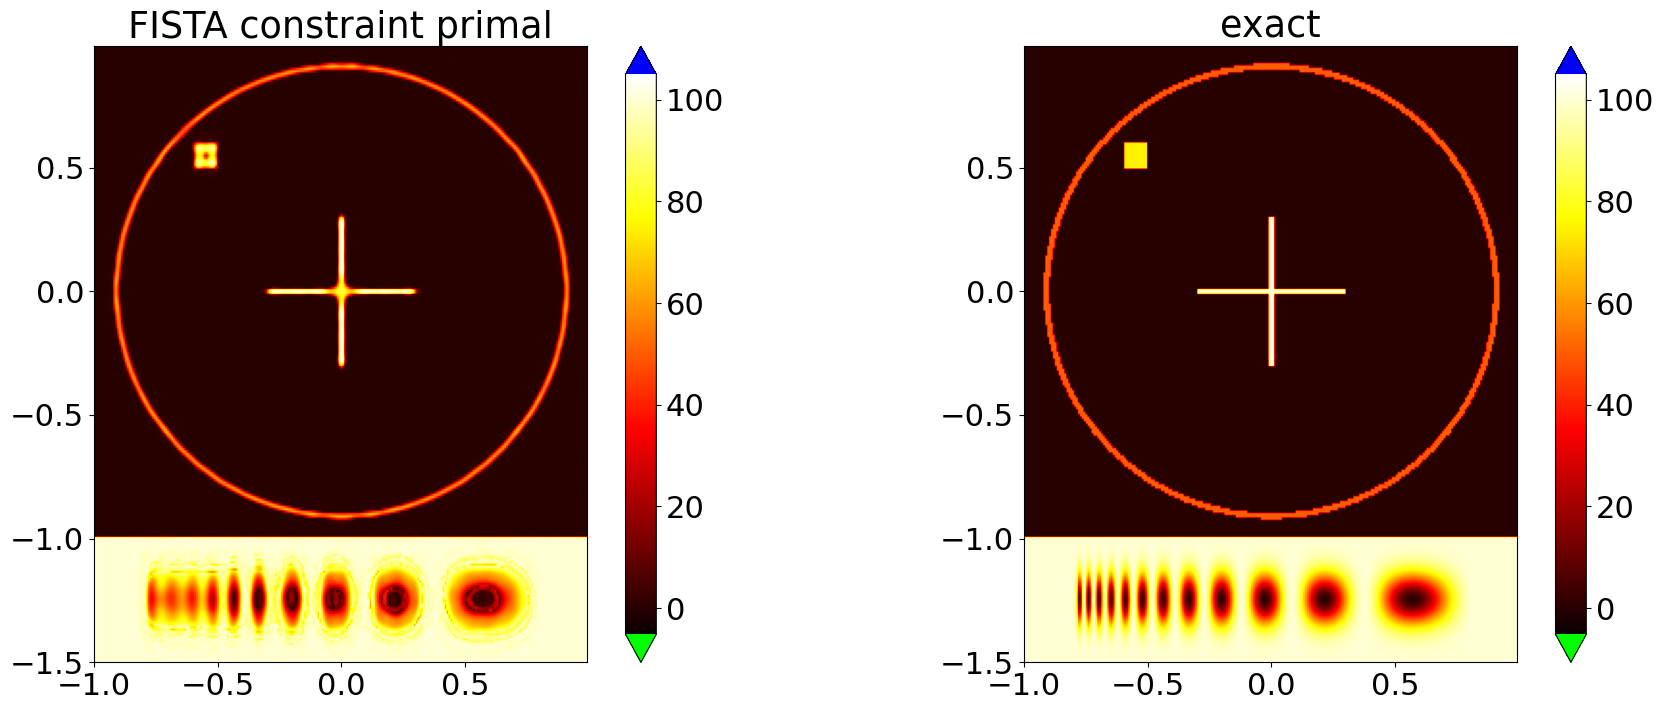

In [13]:
solverFISTA_constr_primal = FISTA(huber_constr_setting,logging_level=logging.DEBUG)
stop_FISTA_constr_primal=DualityGapStopping(solverFISTA_constr_primal,threshold = 1, max_iter=400,logging_level=logging.DEBUG)
f_FISTA_constr_primal, _= solverFISTA_constr_primal.run(stoprule=stop_FISTA_constr_primal)

comparison_plot(grid,exact_sol,f_FISTA_constr_primal,title_left='FISTA constraint primal')

### FISTA applied to the dual setting

2024-07-07 17:13:19,679 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-05, mu_S=0.000e+00 and step length tau=1.005e+00.
 Expected linear convergence rate: 9.968e-01
2024-07-07 17:13:19,732 INFO DualityGapStopping   :: it. 0/400: duality gap=3.514e+06
2024-07-07 17:13:19,734 INFO DualityGapStopping   :: it. 0/400: duality gap=3.514e+06 (1.000e-03)
2024-07-07 17:13:19,788 WARNING TikhonovRegularizationSetting :: duality gap infinite: R(..)=inf, S(..)=1.001e+10, S*(..)=-1.012e+05, R*(..)=-3.105e+03,
2024-07-07 17:13:19,789 INFO DualityGapStopping   :: it. 1/400: duality gap=inf (1.000e-03)
2024-07-07 17:13:19,837 WARNING TikhonovRegularizationSetting :: duality gap infinite: R(..)=inf, S(..)=1.033e+10, S*(..)=-2.007e+05, R*(..)=-2.695e+03,
2024-07-07 17:13:19,839 INFO DualityGapStopping   :: it. 2/400: duality gap=inf (1.000e-03)
2024-07-07 17:13:19,888 WARNING TikhonovRegularizationSetting :: duality gap infinite: R(..)=inf, S(..)=1.060e+10, S*(..)=-

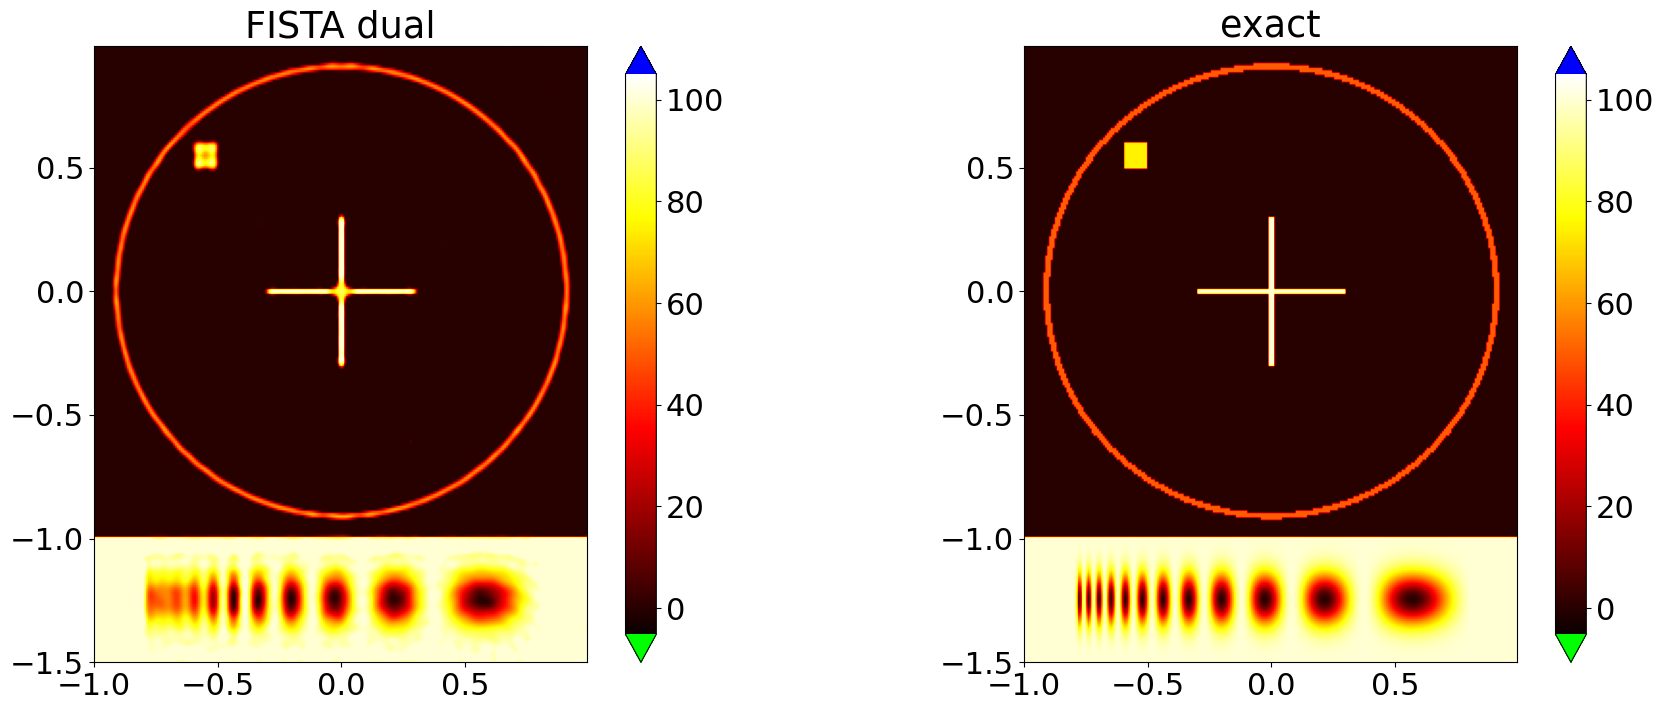

In [14]:
solverFISTA_constr_dual = FISTA(dual_constr_setting,logging_level=logging.DEBUG)
stop_FISTA_constr_dual=DualityGapStopping(solverFISTA_constr_dual,threshold = 1e-3, max_iter=400,logging_level=logging.INFO)
pFISTA_constr_dual, Tstar_pFISTA_constr_dual= solverFISTA_constr_dual.run(stoprule=stop_FISTA_constr_dual)

f_FISTA_constr_dual = huber_constr_setting.dualToPrimal(Tstar_pFISTA_constr_dual,argumentIsOperatorImage=True)
comparison_plot(grid,exact_sol,f_FISTA_constr_dual,title_left='FISTA dual')

### PDHG

In [15]:
solverPDHG_constr = PDHG(huber_constr_setting,logging_level=logging.INFO)
stop_PDHG_constr=DualityGapStopping(solverPDHG_constr,threshold = 1., max_iter=400,logging_level=logging.INFO)
f_PDHG_constr, _= solverPDHG_constr.run(stoprule=stop_PDHG_constr)

comparison_plot(grid,exact_sol,f_PDHG_constr,title_left='PDHG')

2024-07-07 17:14:13,640 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-05 and ||T||=9.946e-01.
 Expected linear convergence rate: 9.937e-01
2024-07-07 17:14:13,676 INFO DualityGapStopping   :: it. 0/400: duality gap=2.637e+06
2024-07-07 17:14:13,677 INFO DualityGapStopping   :: it. 0/400: duality gap=2.637e+06 (1.000e-03)
2024-07-07 17:14:13,787 INFO DualityGapStopping   :: it. 1/400: duality gap=1.342e+06 (1.000e-03)
2024-07-07 17:14:13,834 INFO DualityGapStopping   :: it. 2/400: duality gap=7.719e+05 (1.000e-03)
2024-07-07 17:14:13,877 INFO DualityGapStopping   :: it. 3/400: duality gap=3.824e+05 (1.000e-03)
2024-07-07 17:14:13,927 INFO DualityGapStopping   :: it. 4/400: duality gap=1.640e+05 (1.000e-03)
2024-07-07 17:14:13,977 INFO DualityGapStopping   :: it. 5/400: duality gap=8.556e+04 (1.000e-03)
2024-07-07 17:14:14,044 INFO DualityGapStopping   :: it. 6/400: duality gap=5.843e+04 (1.000e-03)
2024-07-07 17:14:14,101

### comparison of convergence rates of minimization methods

In [ ]:
plt.semilogy(stop_FISTA_constr_primal.gap_stat,label='FISTA primal')
plt.semilogy(stop_FISTA_constr_dual.gap_stat,label='FISTA dual')
plt.semilogy(stop_PDHG_constr.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('Huber data fid., quadratic constr. penalty')

NameError: name 'stop_FISTA_constr_primal' is not defined

20

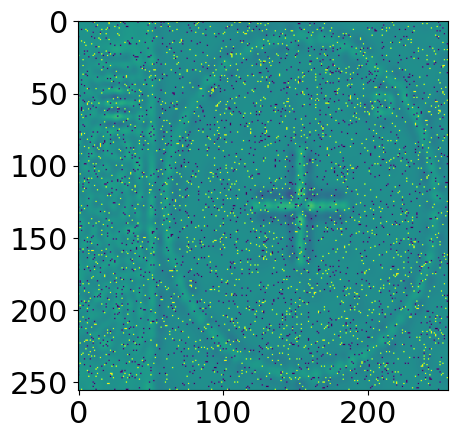

In [ ]:
plt.imshow(pFISTA_constr_dual)
dual_constr_setting.penalty(-alpha*pFISTA_constr_dual), huber_constr_setting.penalty(conv(f_FISTA_constr_dual))
huber_constr_setting.log.level